In [1]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")

In [3]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

# Looking at data

In [18]:
f = jldopen("./data1_better.jld2")
df = f["df"];
fmd = f["metadata"];

In [19]:
N = fmd.N
M = fmd.M
sN = fmd.sN

1000

In [20]:
df.means = [map(df.sol_us[i]) do u reshape(mean(u; dims=2), N+M) end for i in 1:nrow(df)];

In [21]:
df.totbioms = [map(mm) do mu sum(mu[1:N]) end for mm in df.means];

## Total biomass in time

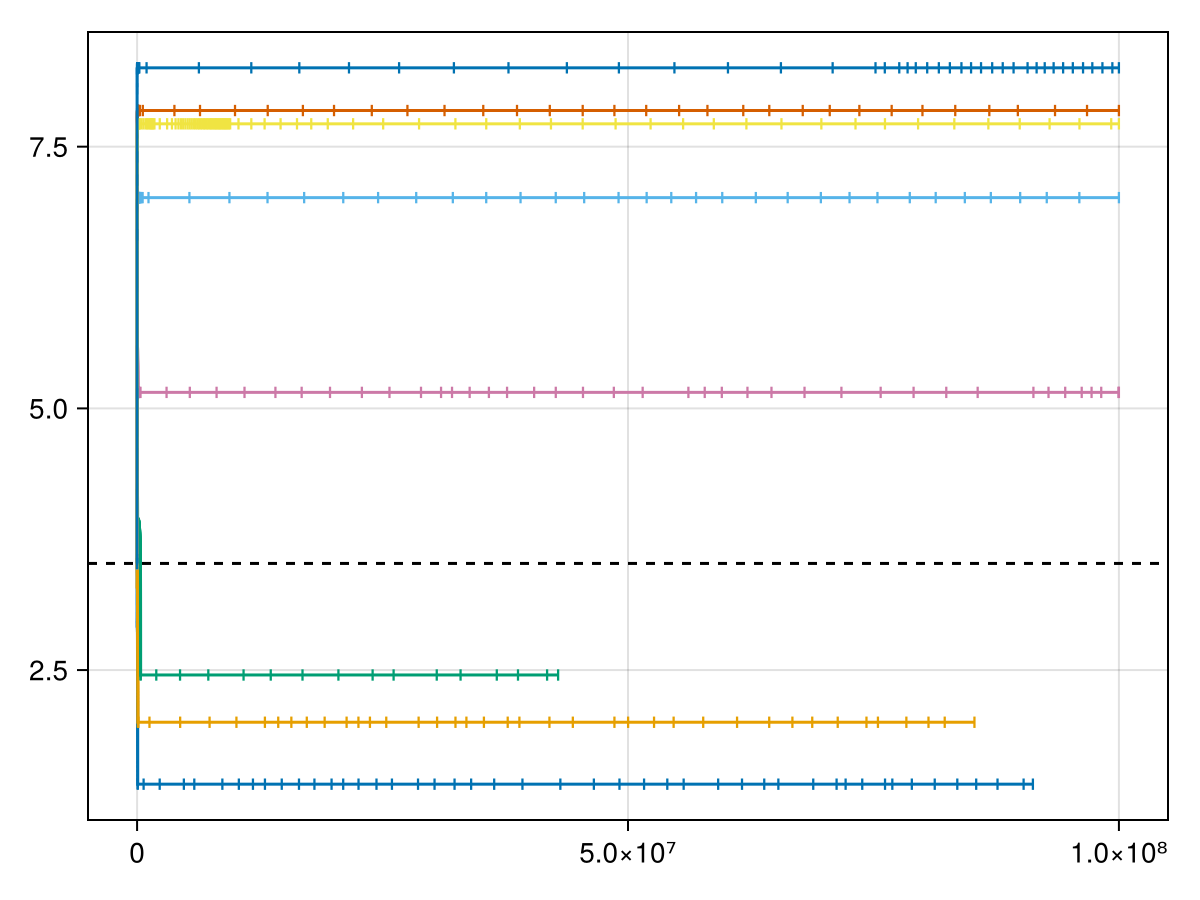

In [24]:
fig = Figure()
ax = Axis(fig[1,1];
    # xscale=log10,
)

for r in eachrow(df)
    scatterlines!(ax, r.sol_ts, r.totbioms;
        marker=:vline
    )
end

hlines!(ax, [df.totbioms[1][1]]; color=:black, linestyle=:dash)

# display(GLMakie.Screen(), fig)

fig

## Plotting community composition

In [11]:
df.commcomps = [map(df.means[i]) do u u[1:N] ./ sum(u[1:N]) end for i in 1:nrow(df)];

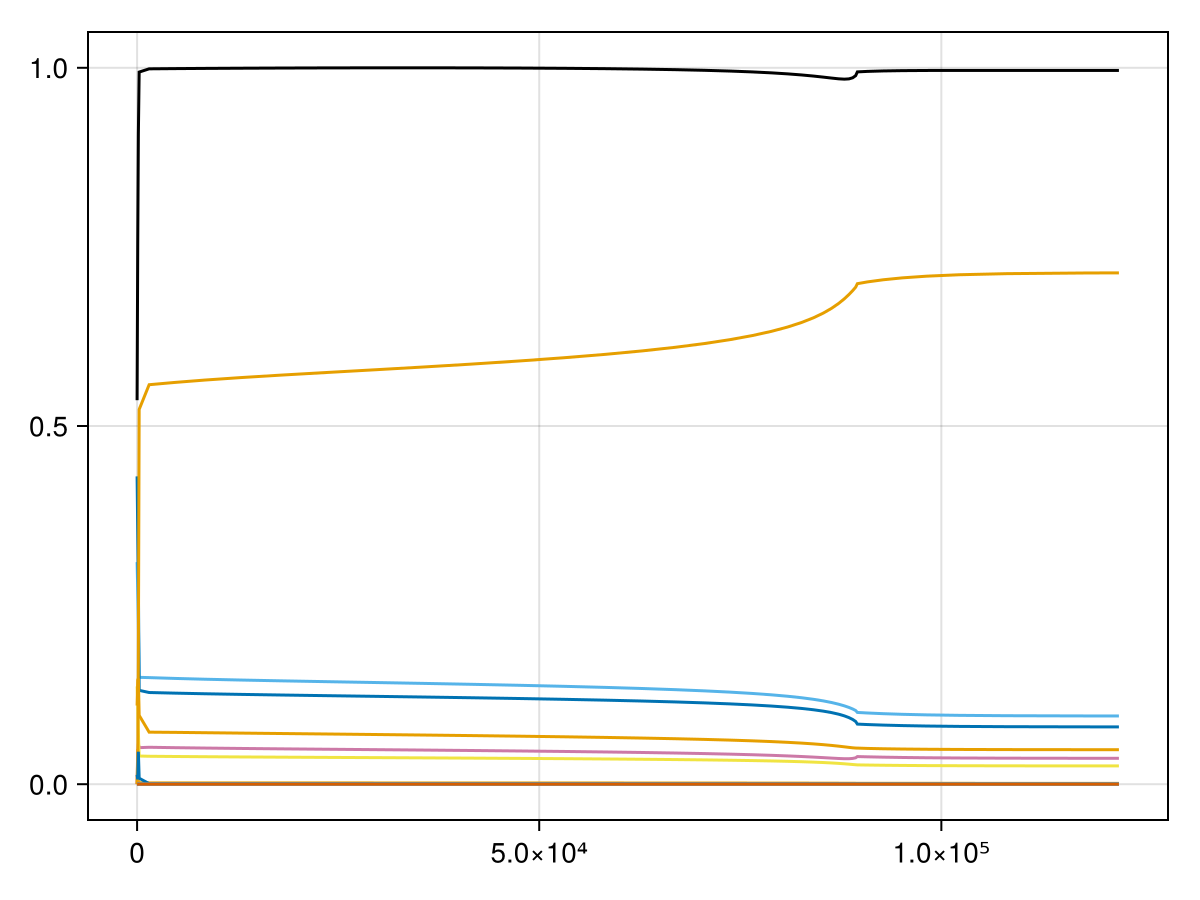

In [12]:
r = df[5,:];

fig = Figure()
ax = Axis(fig[1,1])

for i in 1:N
    lines!(ax, r.sol_ts, getindex.(r.commcomps, i))
end
lines!(ax, r.sol_ts, r.totbioms ./ maximum(r.totbioms); color=:black)

fig

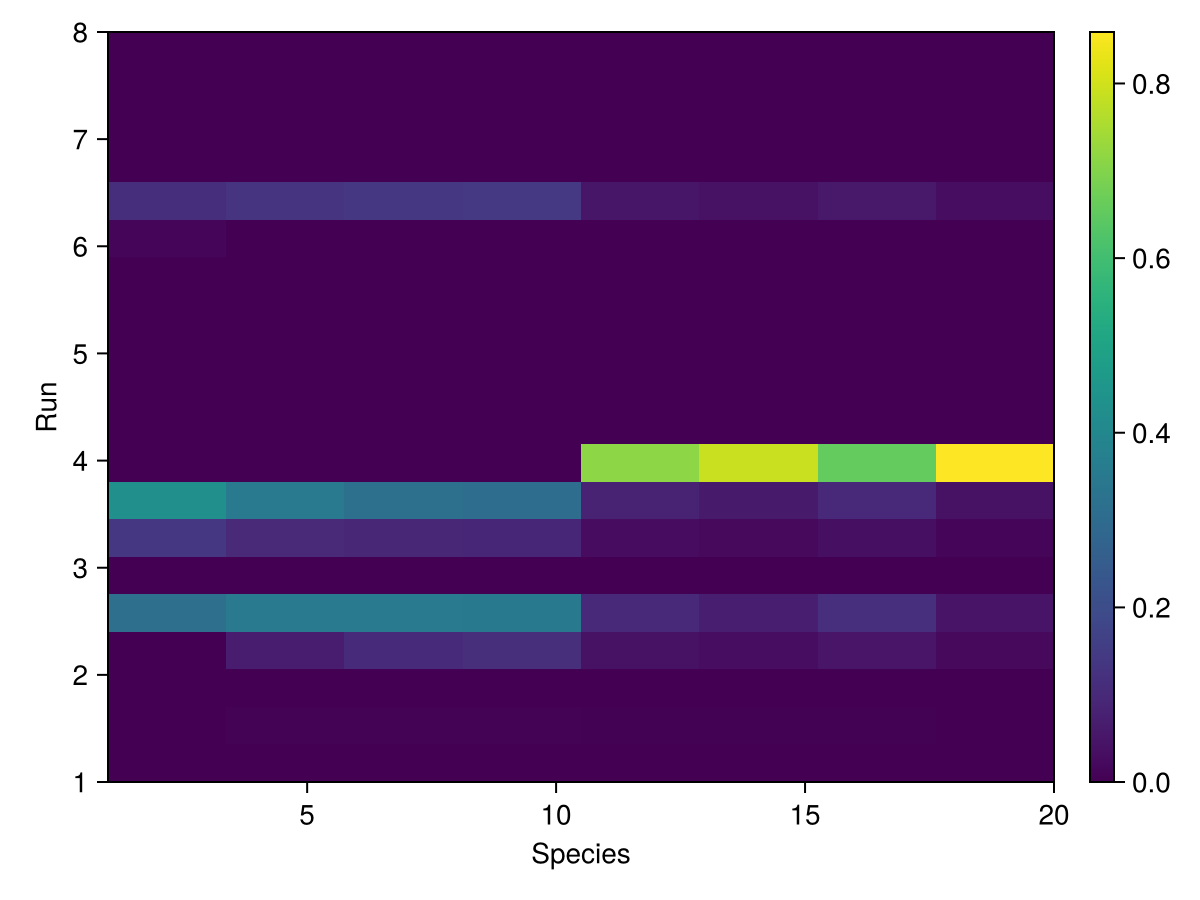

In [17]:
# New plot: heatmap of final relative community composition across runs
nruns = nrow(df)
# each entry of df.commcomps is a vector of length N for each time; take final times
final_comps = [last(df.commcomps[i]) for i in 1:nruns]
# build runs x species matrix: rows=runs, cols=species
comps_mat = permutedims(reduce(hcat, final_comps))
fig = Figure()
ax = Axis(fig[1,1]; xlabel="Species", ylabel="Run")
hm = heatmap!(ax, 1:N, 1:nruns, comps_mat; colormap=:viridis)
Colorbar(fig[1,2], hm)
fig

### Scatter: strains vs relative abundance across runs
This plot shows each strain on the x-axis and its relative abundance (across runs) on the y-axis.

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/scenes.jl:264


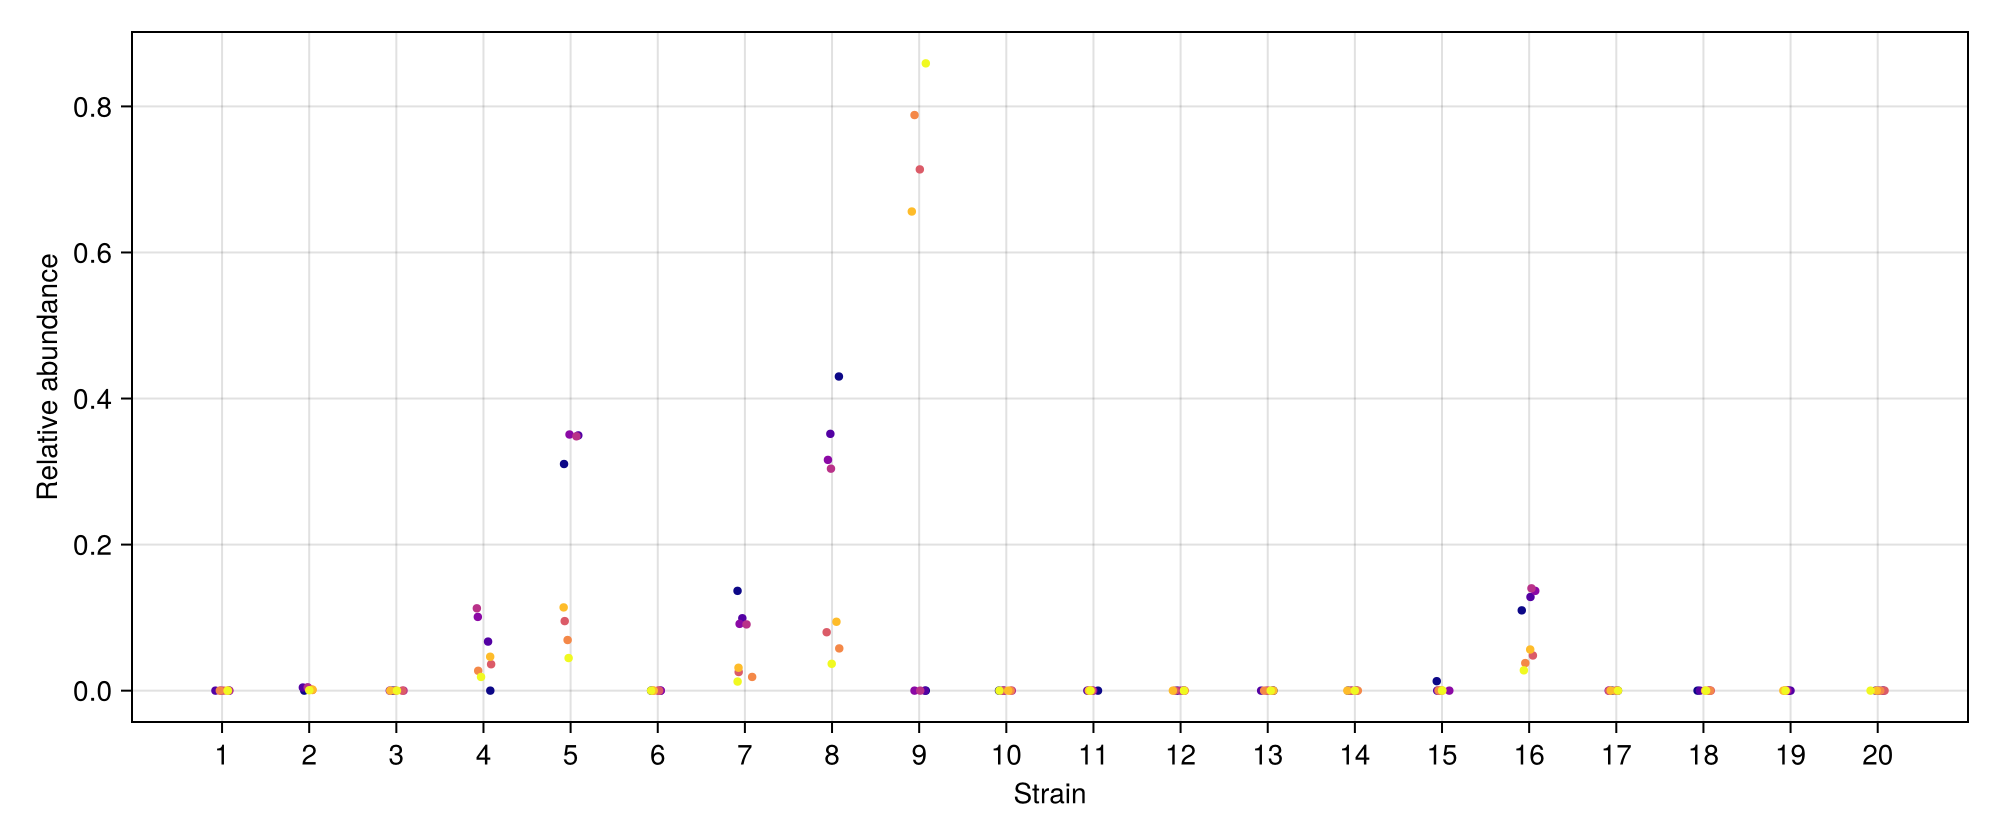

In [19]:
# Scatter: strains (x) vs relative abundance (y) across runs (points with jitter)
nruns = nrow(df)
final_comps = [last(df.commcomps[i]) for i in 1:nruns]
# rows = runs, cols = species
comps_mat = permutedims(reduce(hcat, final_comps))
# x: strain index repeated for each run, y: corresponding relative abundance
x = repeat(1:N, inner=nruns)
y = vec(comps_mat)
# run index for each point (1..nruns repeated per species)
runs = repeat(1:nruns, outer=N)
# add slight jitter to x to separate overlapping points
xj = x .+ 0.18 .* (rand(length(x)) .- 0.5)
fig = Figure(resolution=(1000,420))
ax = Axis(fig[1,1]; xlabel="Strain", ylabel="Relative abundance")
# color points by run using a colormap
scatter!(ax, xj, y; markersize=6, color=runs, colormap=:plasma)
if N <= 50
    ax.xticks = (1:N, string.(1:N))
end
fig

## Claude's attempt

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/scenes.jl:264


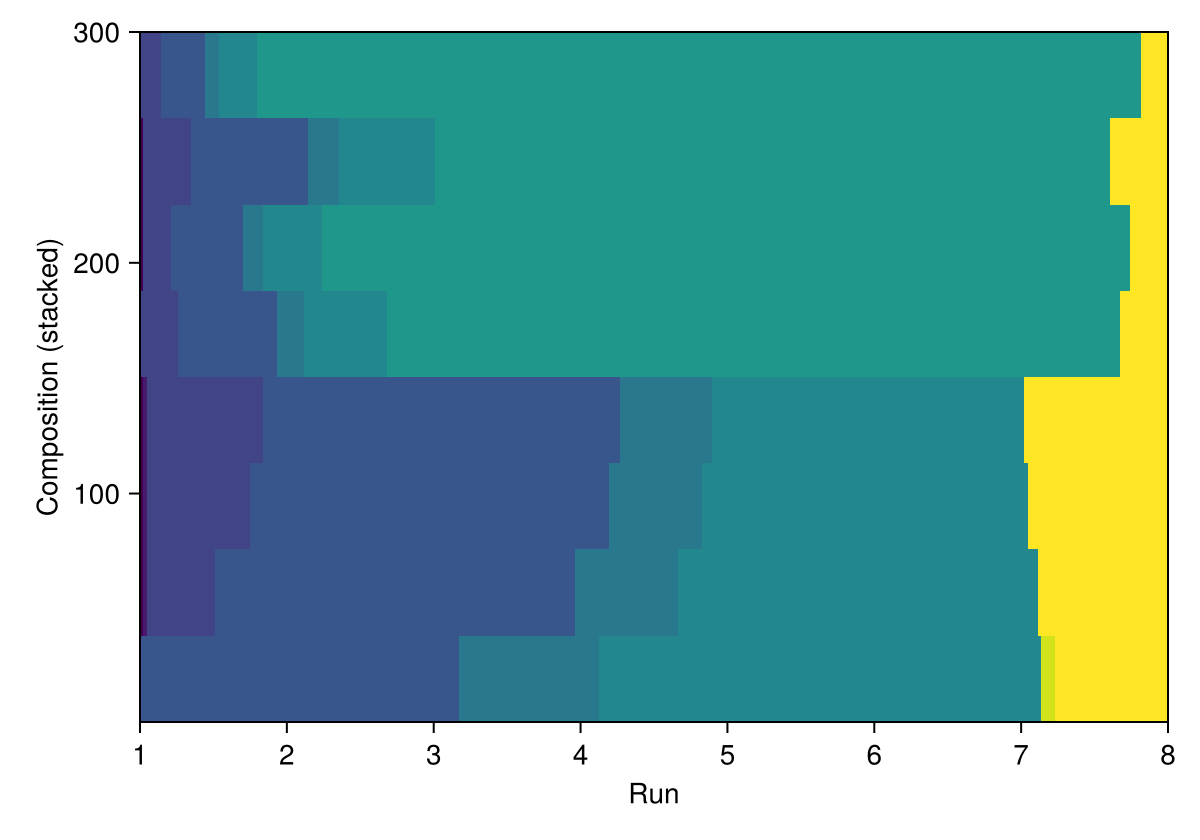

In [22]:
# Stacked-bar-like plot per run using a discrete colour for each strain (rasterized)
nruns = nrow(df)
final_comps = [last(df.commcomps[i]) for i in 1:nruns]
# build runs x species matrix: rows=runs, cols=species
comps_mat = permutedims(reduce(hcat, final_comps))
H = 300  # vertical resolution for each bar (increase for smoother segments)
img = zeros(Int, H, nruns)
for r in 1:nruns
    counts = round.(Int, comps_mat[r, :] * H)
    # ensure counts sum to H
    diff = H - sum(counts)
    if diff > 0
        for k in 1:diff
            counts[mod1(k, N)] += 1
        end
    elseif diff < 0
        for k in 1:-diff
            idx = argmax(counts)
            counts[idx] -= 1
        end
    end
    pos = 1
    for s in 1:N
        if counts[s] > 0
            img[pos:pos+counts[s]-1, r] .= s
            pos += counts[s]
        end
    end
end
# discrete palette for strains (sample from a continuous colormap)
palette = cgrad(:viridis, N)
fig = Figure(resolution=(max(600, 30*nruns), 420))
ax = Axis(fig[1,1]; xlabel="Run", ylabel="Composition (stacked)")
# draw the raster: rows = vertical pixels, cols = runs
hm = heatmap!(ax, 1:nruns, 1:H, img; colormap=palette, interpolate=false)
fig